# VoD Radar-LiDAR End-to-End 발표/제출 노트북

이 노트북은 **발표 데모와 제출 자료**를 동시에 만들 수 있도록 아래 순서로 구성되어 있습니다.

1. 데이터 프레임 불러오기  
2. 데이터 이상치 확인  
3. 이상치 시각화  
4. 전처리  
5. DBSCAN (Radar)  
6. LiDAR 센서 이용 검증  
7. 프레임 기반 이동지역 예측 및 BEV 시각화  
8. 모델 학습  
9. 위험지역 예측

---

## 발표용 핵심 메시지

- 운영 입력은 Radar 중심이며, LiDAR는 오프라인 검증/분석 보조로 사용합니다.
- 단일 프레임 정성 분석 + 다중 프레임 정량 분석을 결합합니다.
- 최종적으로 위험지역을 모델 기반으로 예측하고 BEV에서 직관적으로 시각화합니다.

## 0. 공통 Import + 한글 설정

In [13]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev
import vod_compare_utils as vcu

warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# seaborn이 rcParams를 덮어쓸 수 있어, theme 설정 후 폰트를 다시 고정한다.
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_name = None

if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
elif "Malgun Gothic" in available_fonts:
    font_name = "Malgun Gothic"
elif "NanumGothic" in available_fonts:
    font_name = "NanumGothic"

# 실제 설치된 폰트만 family 목록에 넣어 findfont 경고를 막는다.
family_candidates = [font_name, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_families = []
for fam in family_candidates:
    if fam and fam in available_fonts and fam not in active_families:
        active_families.append(fam)

sns.set_theme(style="whitegrid")

if active_families:
    rc("font", family=active_families)
    matplotlib.rcParams["font.family"] = active_families
else:
    print(f"[warn] 한글 폰트를 찾지 못했습니다. 확인 경로: {FONT_PATH}")

rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False

plt.rcParams["figure.dpi"] = 120

print("ready:", NOTEBOOK_DIR)
print("active_font:", matplotlib.rcParams.get("font.family"))

ready: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
active_font: ['Malgun Gothic', 'Malgun Gothic', 'NanumGothic', 'AppleGothic', 'DejaVu Sans']


## 1. 설정: 데이터 루트/프레임/실험 파라미터

In [14]:
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_PRESENT_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_PRESENT_MAX_POINTS_PER_FRAME", "1800"))
RNG = np.random.default_rng(42)

# DBSCAN 파라미터
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.25"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))

# LiDAR 검증 반경(m)
LIDAR_VERIFY_RADIUS = float(os.environ.get("VOD_LIDAR_VERIFY_RADIUS", "1.8"))

# 이동 예측 파라미터
TRACK_MATCH_DIST = float(os.environ.get("VOD_TRACK_MATCH_DIST", "3.0"))
RADAR_DT_SEC = float(os.environ.get("VOD_RADAR_DT_SEC", str(1.0 / 13.0)))

frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
frames = [fr for fr in frames_all if fr["radar_path"] and fr["radar_path"].is_file()][:MAX_FRAMES]

if not frames:
    raise RuntimeError("동기화된 Radar 프레임이 없습니다. VOD_ROOT/RADAR_MODE를 확인하세요.")

mid_idx = len(frames) // 2
DEMO_FRAME_ID = os.environ.get("VOD_DEMO_FRAME", frames[mid_idx]["frame_id"])

print("DATASET_ROOT:", DATASET_ROOT)
print("RADAR_MODE:", RADAR_MODE)
print("사용 프레임 수:", len(frames), "/", len(frames_all))
print("DEMO_FRAME_ID:", DEMO_FRAME_ID)

DATASET_ROOT: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
RADAR_MODE: 5-scan
사용 프레임 수: 180 / 8682
DEMO_FRAME_ID: 00090


## 2. 데이터 프레임 불러오기

In [15]:
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]

radar_rows = []
for fr in frames:
    radar_path = fr["radar_path"]
    arr = np.fromfile(radar_path, dtype=np.float32)
    if arr.size == 0 or arr.size % 7 != 0:
        continue

    pts = arr.reshape(-1, 7)
    if pts.shape[0] > MAX_POINTS_PER_FRAME:
        take = RNG.choice(pts.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        pts = pts[take]

    df = pd.DataFrame(pts, columns=RADAR_COLS)
    df["frame_id"] = fr["frame_id"]
    radar_rows.append(df)

if not radar_rows:
    raise RuntimeError("Radar DataFrame 생성 실패: 유효한 radar bin이 없습니다.")

radar_df = pd.concat(radar_rows, ignore_index=True)
radar_df["range_xy"] = np.hypot(radar_df["x"], radar_df["y"])
radar_df["range_3d"] = np.sqrt(radar_df["x"]**2 + radar_df["y"]**2 + radar_df["z"]**2)
radar_df["abs_vr"] = radar_df["v_r"].abs()
radar_df["abs_vr_comp"] = radar_df["v_r_compensated"].abs()

print("Radar DataFrame shape:", radar_df.shape)
print("frame_id 개수:", radar_df["frame_id"].nunique())
display(radar_df.head())

Radar DataFrame shape: (197874, 12)
frame_id 개수: 180


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,range_xy,range_3d,abs_vr,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-40.750900,-0.846359,0.003345,0.0,00000,2.814099,2.851665,0.846359,0.003345
1,2.892353,-1.702031,-0.484078,-43.157455,-0.945826,0.000521,0.0,00000,3.355982,3.390715,0.945826,0.000521
2,3.198316,-1.740433,-0.461826,-38.766808,-0.966848,0.008980,0.0,00000,3.641199,3.670370,0.966848,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,5.395137,5.399963,0.313759,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,5.181470,5.217255,1.089766,0.004509


## 3. 데이터 이상치 확인

In [16]:
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time", "range_xy", "abs_vr_comp"]
num_df = radar_df[eda_cols].copy()

print("[기본 통계]")
display(num_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# IQR 이상치
q1 = num_df.quantile(0.25)
q3 = num_df.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
iqr_mask = num_df.lt(lower) | num_df.gt(upper)

# Z-score 이상치
z_abs = ((num_df - num_df.mean()) / num_df.std(ddof=0).replace(0, np.nan)).abs()
z_mask = z_abs > 3.0

outlier_summary = pd.DataFrame({
    "IQR_outlier_%": (iqr_mask.mean() * 100).round(2),
    "Zscore_outlier_%": (z_mask.mean() * 100).round(2),
    "min": num_df.min(),
    "max": num_df.max(),
}).sort_values("IQR_outlier_%", ascending=False)

print("[이상치 요약]")
display(outlier_summary)

[기본 통계]


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
x,197874.0,19.457895,16.793676,-1.173423e+01,0.712424,2.445225,7.871635,14.725405,25.140801,55.025410,83.268020,96.005119
y,197874.0,-0.120691,9.751334,-9.236630e+01,-26.557621,-15.257176,-4.102762,-0.586096,3.797138,15.788169,28.115024,79.485222
z,197874.0,0.328588,2.310976,-2.382982e+01,-5.690946,-2.554592,-0.620343,-0.056133,1.108652,4.583593,7.507550,22.495716
RCS,197874.0,-12.014252,14.052729,-7.385061e+01,-50.722855,-40.770546,-18.712170,-11.723061,-4.149181,9.661556,23.878017,68.442032
v_r,197874.0,-1.377371,1.589619,-2.620905e+01,-3.470989,-2.539789,-2.026997,-1.597600,-0.983832,0.114049,1.665832,26.225527
v_r_compensated,197874.0,0.094391,1.478069,-2.641503e+01,-1.953850,-0.699293,-0.007638,0.000170,0.007149,1.381036,3.812250,28.011051
time,197874.0,-1.983161,1.413327,-4.000000e+00,-4.000000,-4.000000,-3.000000,-2.000000,-1.000000,0.000000,0.000000,0.000000
range_xy,197874.0,21.353579,17.313715,8.306847e-02,1.942452,3.373173,9.630230,16.310836,27.844383,58.107563,85.784182,98.486214
abs_vr_comp,197874.0,0.327118,1.444504,1.815528e-07,0.000082,0.000482,0.002849,0.007360,0.025691,1.529863,3.966109,28.011051


[이상치 요약]


,IQR_outlier_%,Zscore_outlier_%,min,max
v_r_compensated,23.85,0.62,-2.641503e+01,28.011051
abs_vr_comp,20.82,0.61,1.815528e-07,28.011051
z,11.43,1.87,-2.382982e+01,22.495716
y,9.67,1.62,-9.236630e+01,79.485222
RCS,7.06,0.69,-7.385061e+01,68.442032
x,6.13,2.32,-1.173423e+01,96.005119
range_xy,5.74,2.38,8.306847e-02,98.486214
v_r,4.01,0.56,-2.620905e+01,26.225527
time,0.00,0.00,-4.000000e+00,0.000000


## 4. 이상치 시각화

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

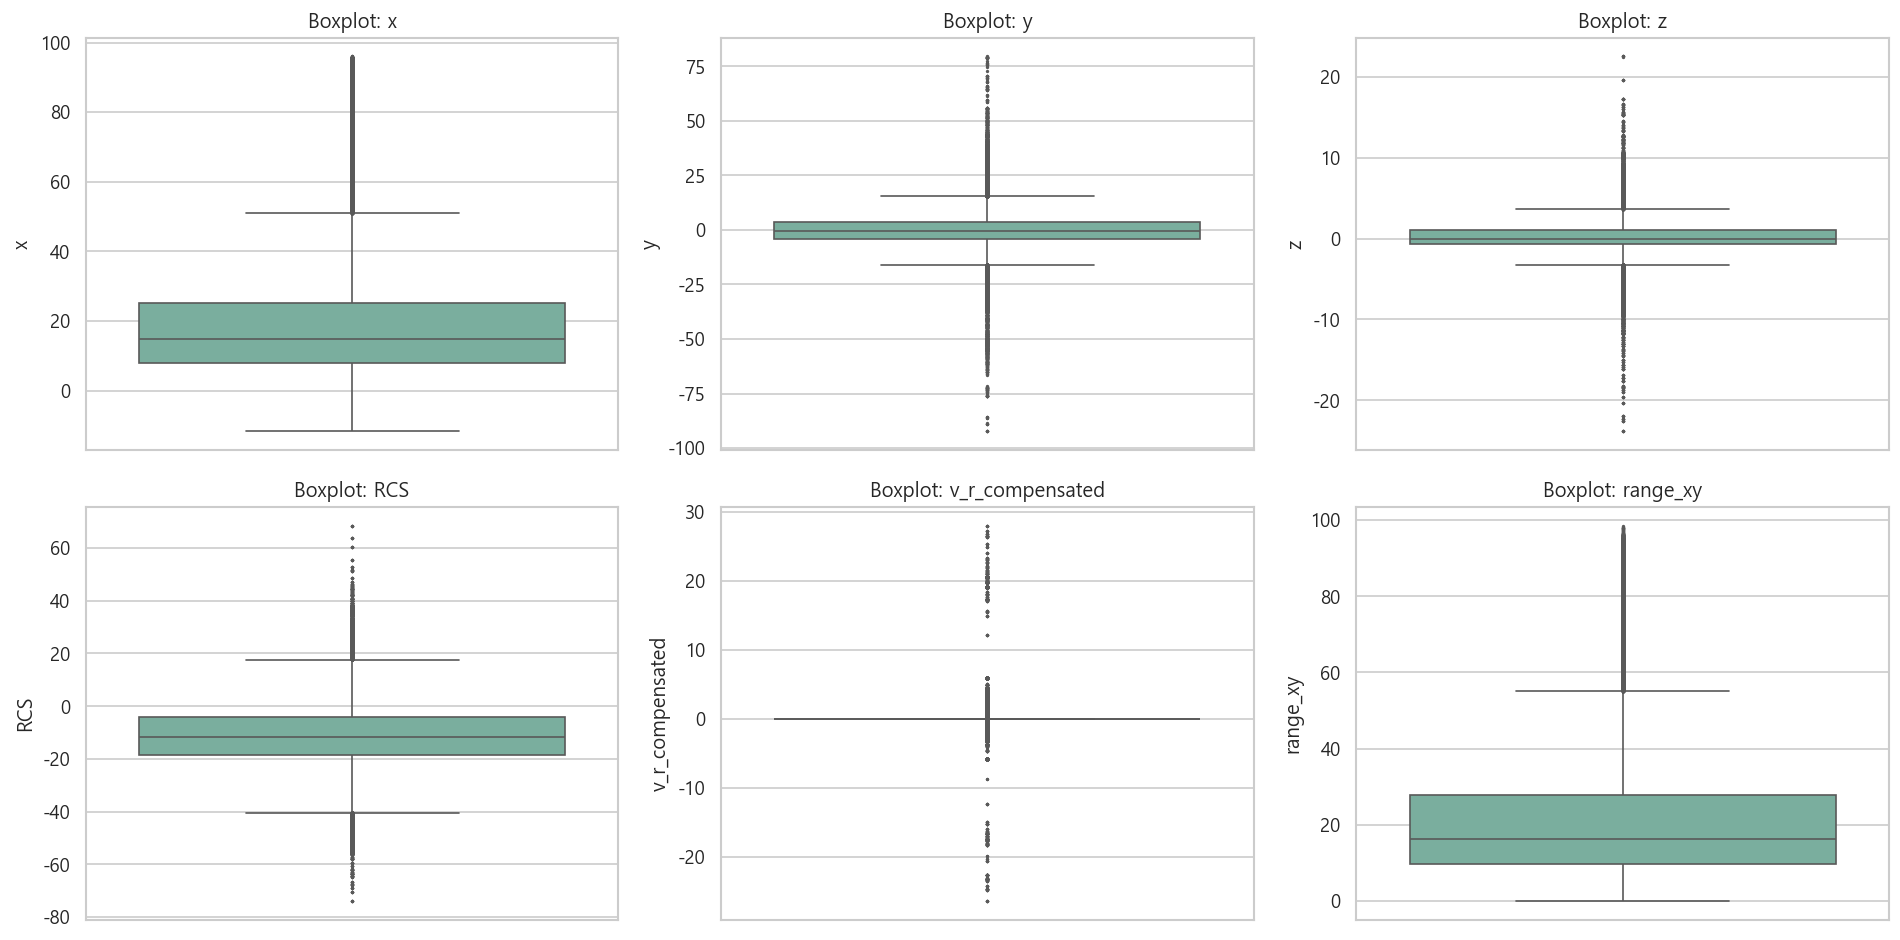

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

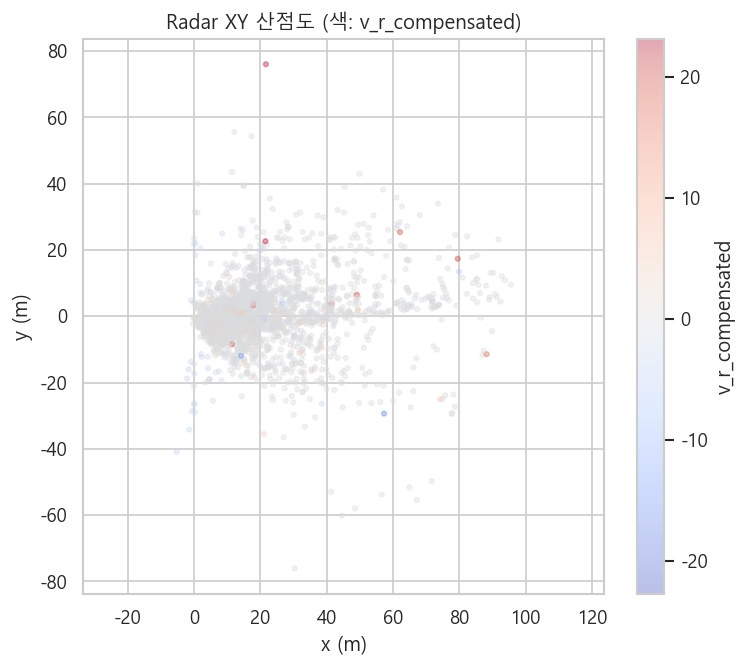

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

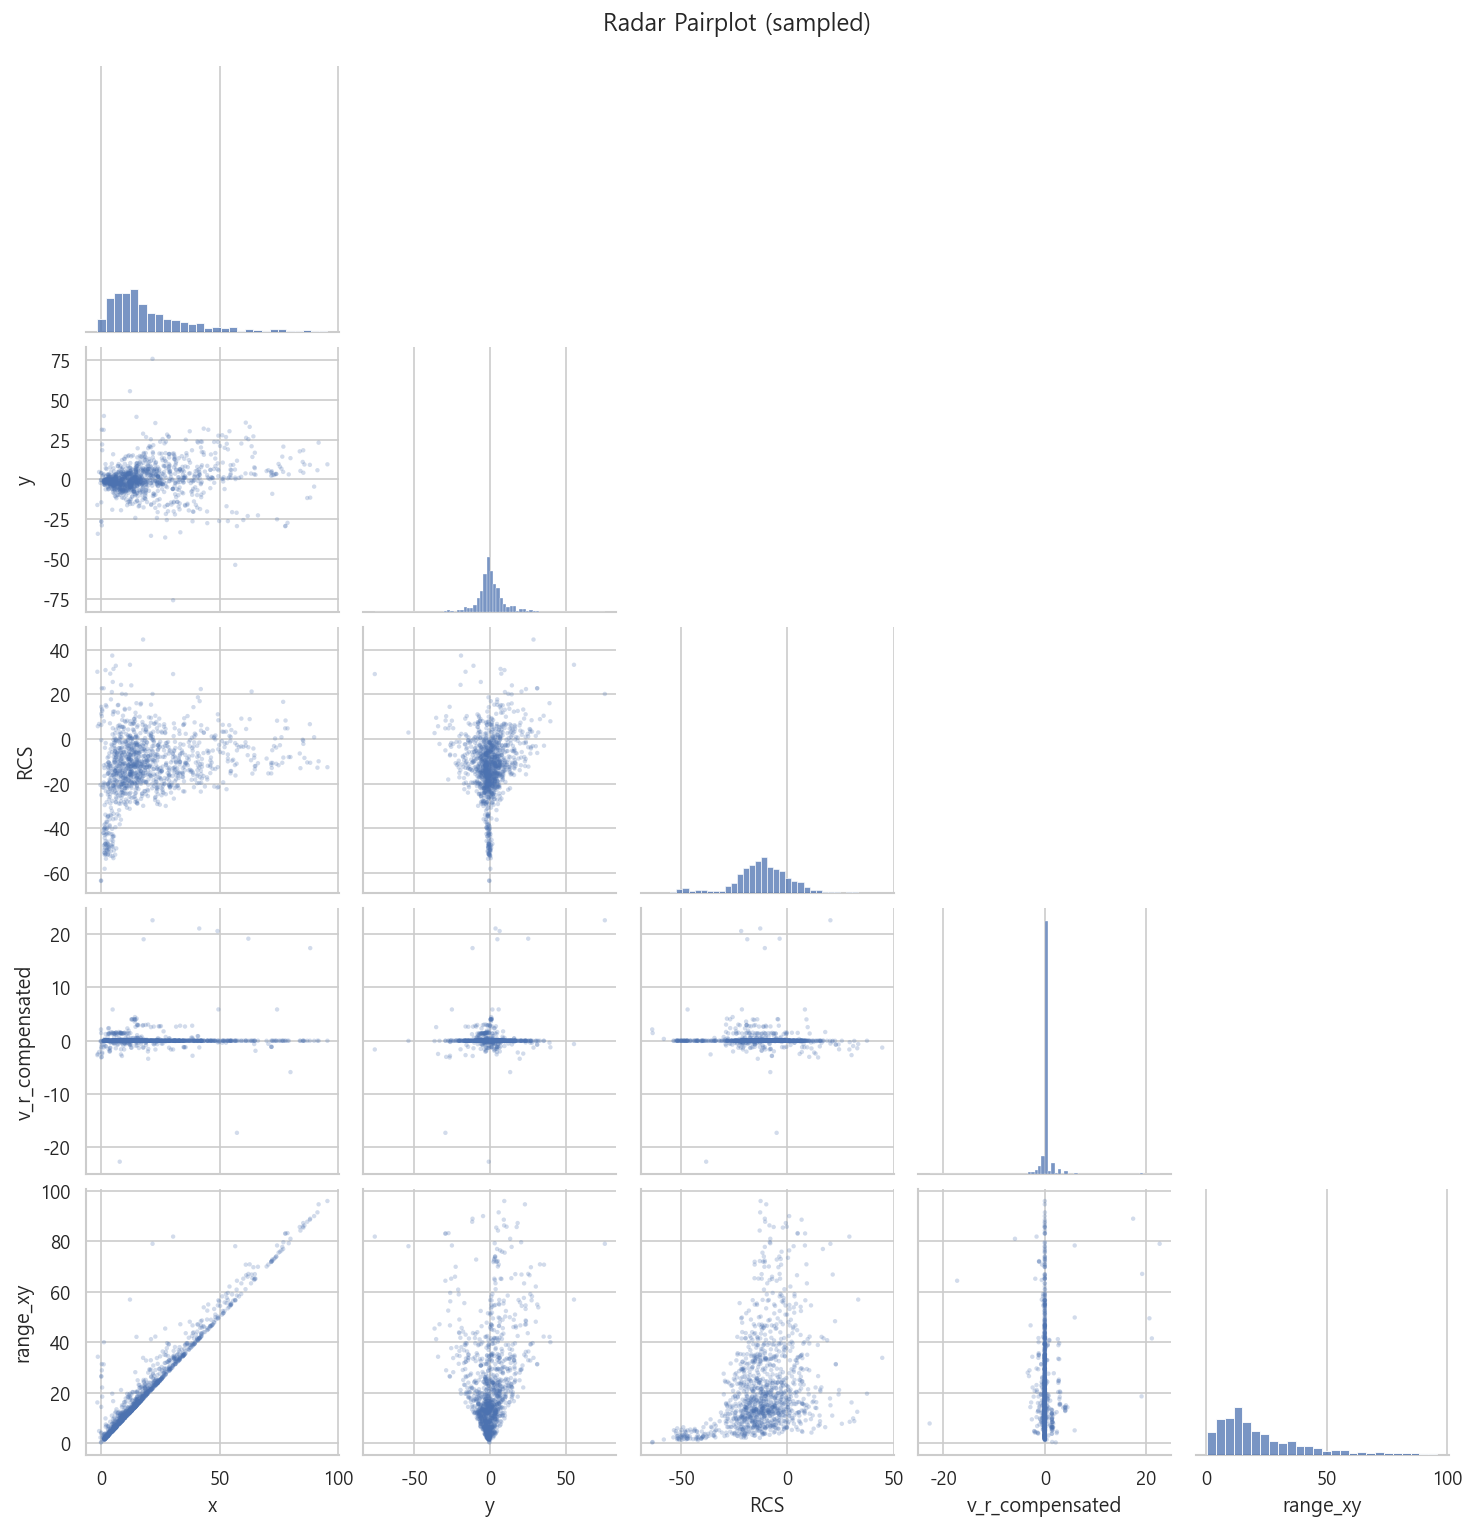

In [17]:
fig_outlier, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
plot_cols = ["x", "y", "z", "RCS", "v_r_compensated", "range_xy"]
for i, col in enumerate(plot_cols):
    sns.boxplot(y=radar_df[col], ax=axes[i], color="#72B6A1", fliersize=1)
    axes[i].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

sample_n = min(2500, len(radar_df))
pair_df = radar_df[["x", "y", "RCS", "v_r_compensated", "range_xy"]].sample(sample_n, random_state=42)

fig_scatter, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pair_df["x"], pair_df["y"], c=pair_df["v_r_compensated"], s=8, cmap="coolwarm", alpha=0.35)
ax.set_title("Radar XY 산점도 (색: v_r_compensated)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(sc, ax=ax, label="v_r_compensated")
plt.axis("equal")
plt.show()

# pairplot은 비용이 크므로 샘플 제한
pairplot_cols = ["x", "y", "RCS", "v_r_compensated", "range_xy"]
pp_df = radar_df[pairplot_cols].sample(min(1200, len(radar_df)), random_state=42)
g = sns.pairplot(pp_df, corner=True, diag_kind="hist", plot_kws={"s": 7, "alpha": 0.25, "edgecolor": "none"})
g.fig.suptitle("Radar Pairplot (sampled)", y=1.02)
plt.show()

## 5. 전처리

In [18]:
# 물리적으로 의미 있는 ROI + 극단치 제거(완전 제거 대신 상위/하위 퍼센타일 클리핑)
phys_mask = (
    (radar_df["x"].between(0.0, 70.0))
    & (radar_df["y"].between(-35.0, 35.0))
    & (radar_df["z"].between(-3.5, 4.0))
    & (radar_df["RCS"].between(-40.0, 40.0))
)

radar_clean_df = radar_df.loc[phys_mask].copy()

for col in ["RCS", "v_r", "v_r_compensated", "range_xy"]:
    lo, hi = radar_clean_df[col].quantile([0.01, 0.99])
    radar_clean_df[col] = radar_clean_df[col].clip(lo, hi)

radar_clean_df["abs_vr_comp"] = radar_clean_df["v_r_compensated"].abs()
radar_clean_df["range_xy"] = np.hypot(radar_clean_df["x"], radar_clean_df["y"])

print(f"전처리 전: {len(radar_df):,} points")
print(f"전처리 후: {len(radar_clean_df):,} points ({len(radar_clean_df)/max(len(radar_df),1)*100:.1f}%)")

display(radar_clean_df.head())

전처리 전: 197,874 points
전처리 후: 164,220 points (83.0%)


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,range_xy,range_3d,abs_vr,abs_vr_comp
2,3.198316,-1.740433,-0.461826,-36.950516,-0.966848,0.008980,0.0,00000,3.641199,3.670370,0.966848,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,5.395137,5.399963,0.313759,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,5.181470,5.217255,1.089766,0.004509
5,5.129763,-2.693486,0.497502,-26.841190,-0.864960,0.124828,0.0,00000,5.793905,5.815225,0.864960,0.124828
6,6.181332,-0.457035,0.114676,-11.083401,0.270091,1.498900,0.0,00000,6.198205,6.199266,0.270091,1.498900


## 6. DBSCAN (Radar)

DBSCAN cluster count: 2 | points: 458


,frame_id,cluster_id,n_points,cx,cy,cz,range_xy,mean_rcs,mean_vr_comp,abs_vr_comp,spread_xy
0,00090,0,370,13.791979,0.265265,0.548755,13.794530,-8.179903,-0.000348,0.001096,9.873948
1,00090,1,29,5.178715,-3.664946,0.017232,6.344361,-21.472494,-1.745099,1.745099,3.445061


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

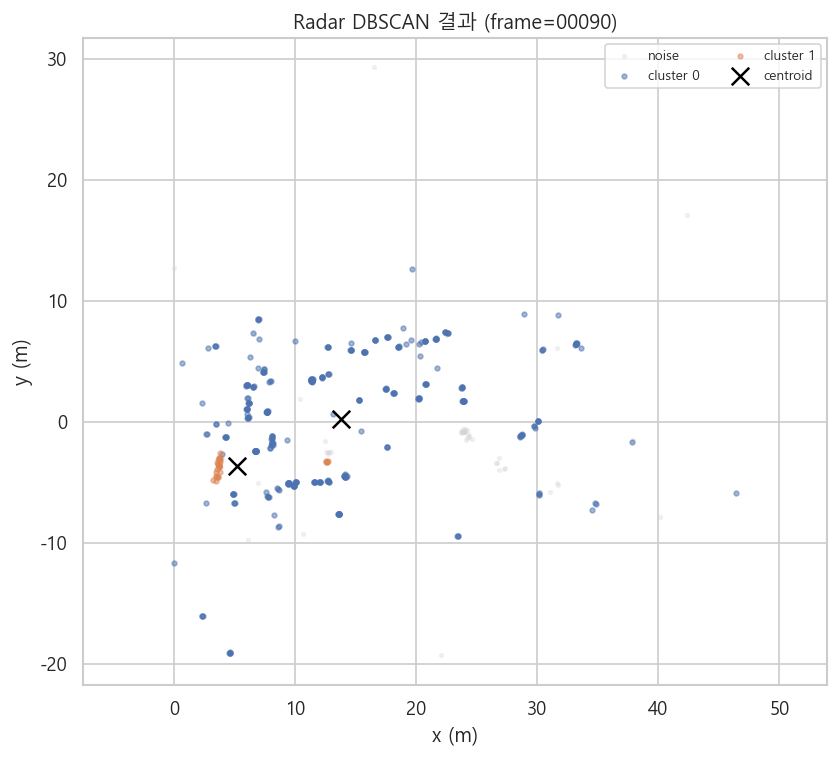

In [19]:
def get_frame_record(frame_id: str) -> dict:
    for fr in frames:
        if fr["frame_id"] == frame_id:
            return fr
    raise KeyError(f"frame_id not found: {frame_id}")


def radar_clusters_for_frame(frame_id: str, eps: float = DBSCAN_EPS, min_samples: int = DBSCAN_MIN_SAMPLES):
    fr_df = radar_clean_df.loc[radar_clean_df["frame_id"] == frame_id].copy()
    if fr_df.empty:
        return fr_df, pd.DataFrame()

    feats = fr_df[["x", "y", "v_r_compensated"]].to_numpy(dtype=np.float32)
    feats_scaled = RobustScaler().fit_transform(feats)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(feats_scaled)
    fr_df["cluster_id"] = labels

    rows = []
    for cid, grp in fr_df.groupby("cluster_id"):
        if cid < 0:
            continue
        cx = float(grp["x"].mean())
        cy = float(grp["y"].mean())
        cz = float(grp["z"].mean())
        rows.append(
            {
                "frame_id": frame_id,
                "cluster_id": int(cid),
                "n_points": int(len(grp)),
                "cx": cx,
                "cy": cy,
                "cz": cz,
                "range_xy": float(np.hypot(cx, cy)),
                "mean_rcs": float(grp["RCS"].mean()),
                "mean_vr_comp": float(grp["v_r_compensated"].mean()),
                "abs_vr_comp": float(grp["v_r_compensated"].abs().mean()),
                "spread_xy": float(np.sqrt(grp[["x", "y"]].var(ddof=0).sum())),
            }
        )
    clu_df = pd.DataFrame(rows)
    return fr_df, clu_df


frame_dbscan_df, cluster_df = radar_clusters_for_frame(DEMO_FRAME_ID)
print("DBSCAN cluster count:", len(cluster_df), "| points:", len(frame_dbscan_df))
display(cluster_df.head())

fig_dbscan, ax = plt.subplots(figsize=(8, 7))
noise = frame_dbscan_df[frame_dbscan_df["cluster_id"] < 0]
ax.scatter(noise["x"], noise["y"], s=5, c="lightgray", alpha=0.25, label="noise")

for cid, grp in frame_dbscan_df[frame_dbscan_df["cluster_id"] >= 0].groupby("cluster_id"):
    ax.scatter(grp["x"], grp["y"], s=8, alpha=0.5, label=f"cluster {cid}")

if not cluster_df.empty:
    ax.scatter(cluster_df["cx"], cluster_df["cy"], s=110, c="black", marker="x", label="centroid")

ax.set_title(f"Radar DBSCAN 결과 (frame={DEMO_FRAME_ID})")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.axis("equal")
ax.legend(loc="upper right", fontsize=8, ncols=2)
plt.show()

## 7. LiDAR 센서 이용 검증

,frame_id,cluster_id,n_points,cx,cy,cz,range_xy,mean_rcs,mean_vr_comp,abs_vr_comp,spread_xy,lidar_nearest_dist,lidar_verified
0,00090,0,370,13.791979,0.265265,0.548755,13.794530,-8.179903,-0.000348,0.001096,9.873948,0.524411,True
1,00090,1,29,5.178715,-3.664946,0.017232,6.344361,-21.472494,-1.745099,1.745099,3.445061,0.038398,True


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

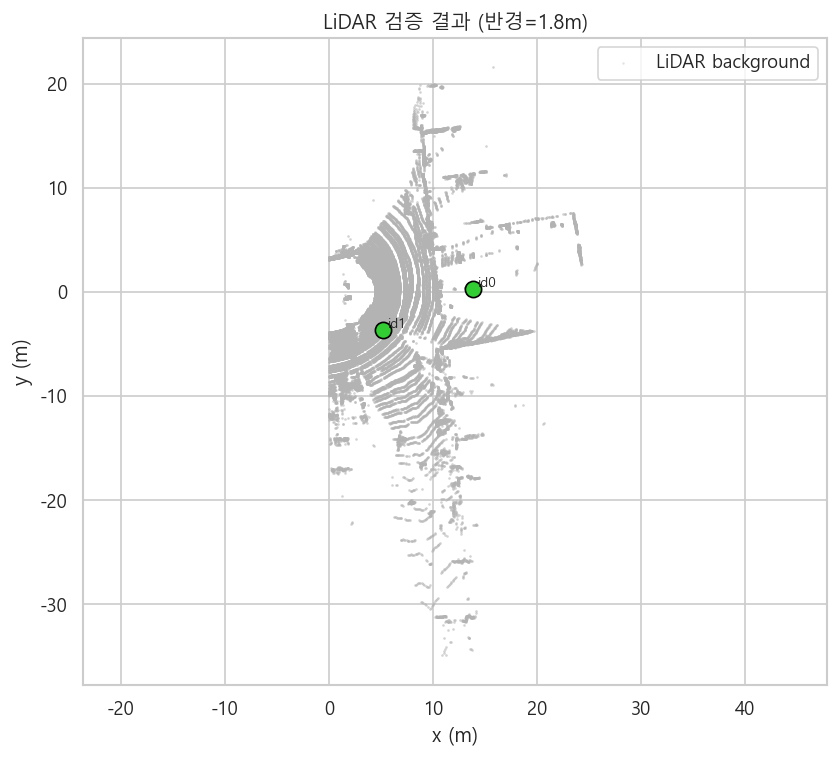

In [20]:
demo_frame = get_frame_record(DEMO_FRAME_ID)
lidar_pts = bev.parse_lidar_bin(demo_frame["lidar_path"]) if demo_frame["lidar_path"].is_file() else np.zeros((0, 4), dtype=np.float32)

if cluster_df.empty:
    print("클러스터가 없어 LiDAR 검증을 생략합니다.")
    cluster_verified_df = cluster_df.copy()
else:
    lidar_xy = lidar_pts[:, :2] if lidar_pts.size > 0 else np.zeros((0, 2), dtype=np.float32)
    if len(lidar_xy) > 0:
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(lidar_xy)
        dists, _ = nn.kneighbors(cluster_df[["cx", "cy"]].to_numpy())
        cluster_verified_df = cluster_df.copy()
        cluster_verified_df["lidar_nearest_dist"] = dists[:, 0]
        cluster_verified_df["lidar_verified"] = cluster_verified_df["lidar_nearest_dist"] <= LIDAR_VERIFY_RADIUS
    else:
        cluster_verified_df = cluster_df.copy()
        cluster_verified_df["lidar_nearest_dist"] = np.nan
        cluster_verified_df["lidar_verified"] = False

    display(cluster_verified_df.sort_values(["lidar_verified", "n_points"], ascending=[False, False]))

fig_verify, ax = plt.subplots(figsize=(8, 7))
if lidar_pts.size > 0:
    m = (
        (lidar_pts[:, 0] >= 0.0)
        & (lidar_pts[:, 0] <= 70.0)
        & (lidar_pts[:, 1] >= -35.0)
        & (lidar_pts[:, 1] <= 35.0)
    )
    bg = lidar_pts[m]
    ax.scatter(bg[:, 0], bg[:, 1], s=0.25, c="0.7", alpha=0.35, label="LiDAR background")

if not cluster_df.empty:
    for _, r in cluster_verified_df.iterrows():
        color = "limegreen" if bool(r["lidar_verified"]) else "orangered"
        ax.scatter(r["cx"], r["cy"], c=color, s=95, edgecolor="black")
        ax.text(r["cx"] + 0.4, r["cy"] + 0.2, f"id{int(r['cluster_id'])}", fontsize=8)

ax.set_title(f"LiDAR 검증 결과 (반경={LIDAR_VERIFY_RADIUS:.1f}m)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.axis("equal")
ax.legend(loc="upper right")
plt.show()

## 8. 프레임 기반 이동지역 예측 및 BEV 시각화

matched motions: 12 | window: ['00087', '00088', '00089', '00090', '00091', '00092', '00093']


,prev_frame,cur_frame,x0,y0,x1,y1,vx,vy,speed_mps
0,00087,00088,14.809456,0.317205,13.738449,0.217203,-13.923088,-1.300024,13.983649
1,00087,00088,4.565540,-3.735056,4.476239,-3.931625,-1.160921,-2.555403,2.806745
2,00088,00089,13.738449,0.217203,13.726503,0.217424,-0.155294,0.002876,0.155321
3,00088,00089,4.476239,-3.931625,4.706643,-3.629879,2.995251,3.922700,4.935494
4,00089,00090,13.726503,0.217424,13.791979,0.265265,0.851181,0.621930,1.054185


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

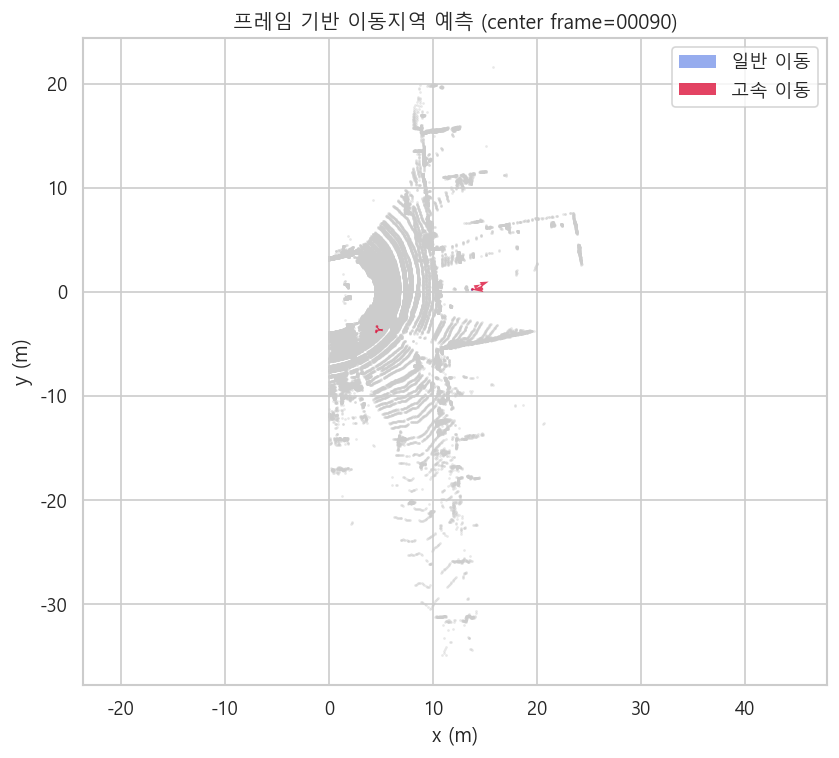

In [21]:
def cluster_centers(frame_id: str) -> pd.DataFrame:
    _, cdf = radar_clusters_for_frame(frame_id)
    return cdf

# 데모 프레임 주변 윈도우
frame_ids = [fr["frame_id"] for fr in frames]
if DEMO_FRAME_ID not in frame_ids:
    DEMO_FRAME_ID = frame_ids[len(frame_ids)//2]
center_idx = frame_ids.index(DEMO_FRAME_ID)
win_l = max(0, center_idx - 3)
win_r = min(len(frame_ids), center_idx + 4)
window_ids = frame_ids[win_l:win_r]

motions = []
for prev_id, cur_id in zip(window_ids[:-1], window_ids[1:]):
    prev_c = cluster_centers(prev_id)
    cur_c = cluster_centers(cur_id)
    if prev_c.empty or cur_c.empty:
        continue

    prev_xy = prev_c[["cx", "cy"]].to_numpy()
    cur_xy = cur_c[["cx", "cy"]].to_numpy()
    nn = NearestNeighbors(n_neighbors=1).fit(cur_xy)
    dists, inds = nn.kneighbors(prev_xy)

    for i, (dist, j) in enumerate(zip(dists[:, 0], inds[:, 0])):
        if float(dist) > TRACK_MATCH_DIST:
            continue
        p = prev_xy[i]
        c = cur_xy[j]
        vx = float((c[0] - p[0]) / max(RADAR_DT_SEC, 1e-6))
        vy = float((c[1] - p[1]) / max(RADAR_DT_SEC, 1e-6))
        speed = float(np.hypot(vx, vy))
        motions.append(
            {
                "prev_frame": prev_id,
                "cur_frame": cur_id,
                "x0": float(p[0]),
                "y0": float(p[1]),
                "x1": float(c[0]),
                "y1": float(c[1]),
                "vx": vx,
                "vy": vy,
                "speed_mps": speed,
            }
        )

motion_df = pd.DataFrame(motions)
print("matched motions:", len(motion_df), "| window:", window_ids)
display(motion_df.head())

fig_motion, ax = plt.subplots(figsize=(8, 7))
if lidar_pts.size > 0:
    m = (
        (lidar_pts[:, 0] >= 0.0)
        & (lidar_pts[:, 0] <= 70.0)
        & (lidar_pts[:, 1] >= -35.0)
        & (lidar_pts[:, 1] <= 35.0)
    )
    bg = lidar_pts[m]
    ax.scatter(bg[:, 0], bg[:, 1], s=0.2, c="0.8", alpha=0.3)

if not motion_df.empty:
    high_move = motion_df[motion_df["speed_mps"] >= 2.0]
    low_move = motion_df[motion_df["speed_mps"] < 2.0]

    ax.quiver(
        low_move["x0"], low_move["y0"],
        low_move["x1"] - low_move["x0"], low_move["y1"] - low_move["y0"],
        angles="xy", scale_units="xy", scale=1, color="royalblue", alpha=0.55, width=0.003,
        label="일반 이동"
    )
    ax.quiver(
        high_move["x0"], high_move["y0"],
        high_move["x1"] - high_move["x0"], high_move["y1"] - high_move["y0"],
        angles="xy", scale_units="xy", scale=1, color="crimson", alpha=0.8, width=0.004,
        label="고속 이동"
    )

ax.set_title(f"프레임 기반 이동지역 예측 (center frame={DEMO_FRAME_ID})")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.axis("equal")
ax.legend(loc="upper right")
plt.show()

## 9. 모델 학습 (Cluster 단위 Risk 분류기)

> 추가한 내용: 발표 시 정량 근거를 강화하기 위해, 클러스터 특징으로 `low / medium / high` 위험도를 분류하는 경량 모델을 학습합니다.

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

              precision    recall  f1-score   support

        high      1.000     1.000     1.000         9
         low      1.000     1.000     1.000       157
      medium      1.000     1.000     1.000        12

    accuracy                          1.000       178
   macro avg      1.000     1.000     1.000       178
weighted avg      1.000     1.000     1.000       178



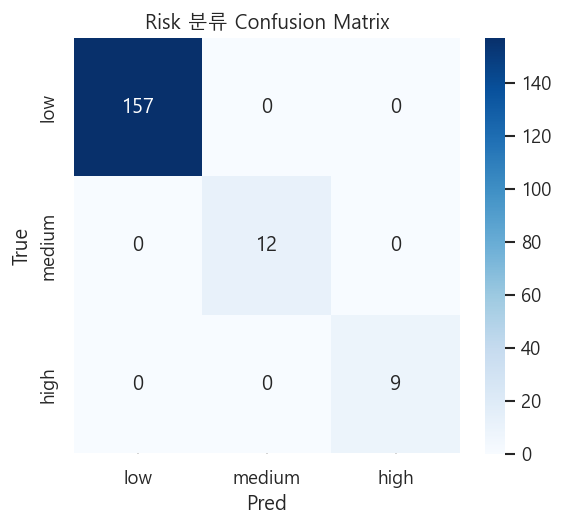

,n_points,range_xy,mean_rcs,mean_vr_comp,abs_vr_comp,spread_xy,ttc,risk_label
0,242,17.087896,-8.757268,0.637360,0.730121,13.263062,23.404210,low
1,499,18.612554,-9.541173,0.642979,0.723969,14.714235,25.709051,low
2,761,18.942836,-9.438219,0.603401,0.684038,14.909649,27.692648,low
3,1027,18.831574,-9.487097,0.607958,0.688667,14.988768,27.344975,low
4,1294,19.032781,-9.504389,0.576523,0.657619,15.415575,28.941963,low


In [22]:
def nearest_lidar_dist_for_clusters(frame_rec: dict, clu_df: pd.DataFrame) -> np.ndarray:
    if clu_df.empty:
        return np.zeros((0,), dtype=np.float32)
    lidar_path = frame_rec.get("lidar_path")
    if (lidar_path is None) or (not Path(lidar_path).is_file()):
        return np.full((len(clu_df),), np.nan, dtype=np.float32)

    lidar_pts_local = bev.parse_lidar_bin(Path(lidar_path))
    lidar_xy_local = lidar_pts_local[:, :2]
    if len(lidar_xy_local) == 0:
        return np.full((len(clu_df),), np.nan, dtype=np.float32)

    nn_local = NearestNeighbors(n_neighbors=1)
    nn_local.fit(lidar_xy_local)
    d, _ = nn_local.kneighbors(clu_df[["cx", "cy"]].to_numpy())
    return d[:, 0]


train_rows = []
for fr in frames:
    fid = fr["frame_id"]
    _, cdf = radar_clusters_for_frame(fid)
    if cdf.empty:
        continue

    dists = nearest_lidar_dist_for_clusters(fr, cdf)
    cdf = cdf.copy()
    cdf["lidar_nearest_dist"] = dists

    # TTC 근사: 가까우면서 접근속도가 클수록 위험
    cdf["ttc"] = cdf["range_xy"] / (cdf["abs_vr_comp"].clip(lower=0.2))

    # 규칙 기반 pseudo label
    cond_high = (cdf["ttc"] < 3.0) | ((cdf["range_xy"] < 18.0) & (cdf["abs_vr_comp"] > 2.5))
    cond_med = (cdf["ttc"] >= 3.0) & (cdf["ttc"] < 7.0)

    label = np.where(cond_high, "high", np.where(cond_med, "medium", "low"))

    # LiDAR 근접 검증 정보를 반영해 label 안정화
    if np.isfinite(cdf["lidar_nearest_dist"]).any():
        weak = cdf["lidar_nearest_dist"] > 3.0
        label = np.where((label == "high") & weak, "medium", label)

    cdf["risk_label"] = label
    train_rows.append(cdf)

risk_train_df = pd.concat(train_rows, ignore_index=True) if train_rows else pd.DataFrame()

feature_cols = [
    "n_points", "range_xy", "mean_rcs", "mean_vr_comp", "abs_vr_comp", "spread_xy", "ttc"
]

if risk_train_df.empty or risk_train_df["risk_label"].nunique() < 2:
    raise RuntimeError("학습 데이터가 부족합니다. MAX_FRAMES/DBSCAN 파라미터를 조정하세요.")

X = risk_train_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(risk_train_df[feature_cols].median())
y = risk_train_df["risk_label"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

risk_clf = Pipeline(
    steps=[
        ("scaler", RobustScaler()),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=220,
                max_depth=8,
                min_samples_leaf=3,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)
risk_clf.fit(X_train, y_train)

y_pred = risk_clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

labels = ["low", "medium", "high"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig_cm, ax = plt.subplots(figsize=(5.2, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Risk 분류 Confusion Matrix")
ax.set_xlabel("Pred")
ax.set_ylabel("True")
plt.show()

display(risk_train_df[feature_cols + ["risk_label"]].head())

## 10. 위험지역 예측 및 BEV 시각화

,frame_id,cluster_id,n_points,cx,cy,cz,range_xy,mean_rcs,mean_vr_comp,abs_vr_comp,spread_xy,ttc,risk_pred,risk_score
1,00090,1,29,5.178715,-3.664946,0.017232,6.344361,-21.472494,-1.745099,1.745099,3.445061,3.635532,medium,0.65
0,00090,0,370,13.791979,0.265265,0.548755,13.794530,-8.179903,-0.000348,0.001096,9.873948,68.972648,low,0.35


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'Ap

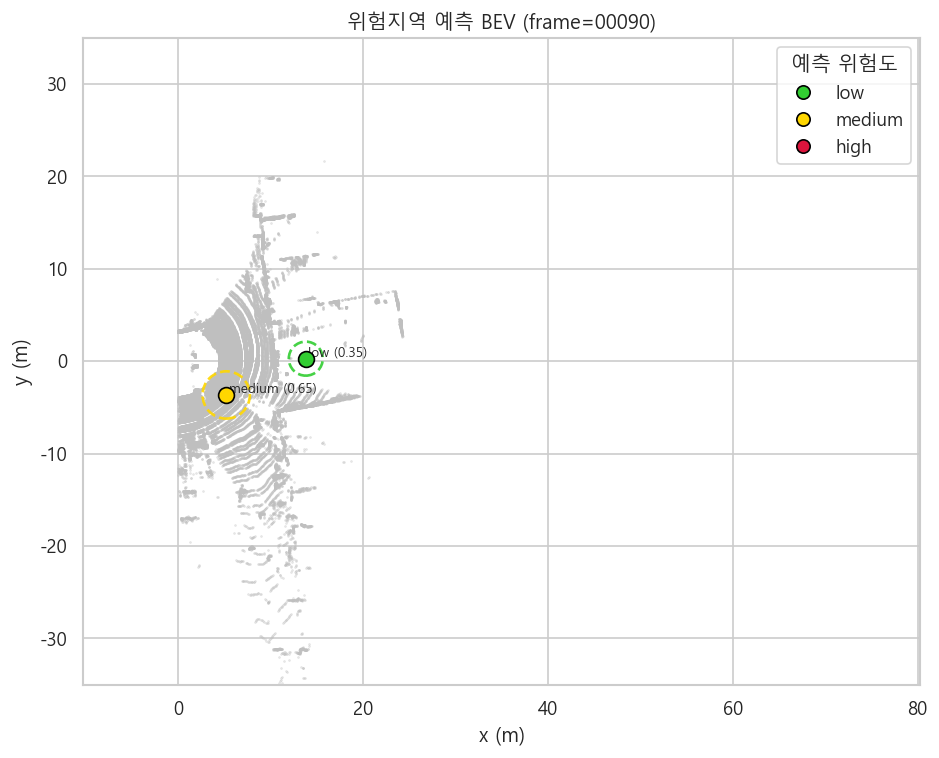

In [23]:
if cluster_df.empty:
    raise RuntimeError("DEMO 프레임에서 클러스터가 없어 위험 예측을 진행할 수 없습니다.")

infer_df = cluster_df.copy()
infer_df["ttc"] = infer_df["range_xy"] / infer_df["abs_vr_comp"].clip(lower=0.2)
X_infer = infer_df[["n_points", "range_xy", "mean_rcs", "mean_vr_comp", "abs_vr_comp", "spread_xy", "ttc"]]
X_infer = X_infer.replace([np.inf, -np.inf], np.nan).fillna(X_infer.median())

infer_df["risk_pred"] = risk_clf.predict(X_infer)
risk_score_map = {"low": 0.35, "medium": 0.65, "high": 0.9}
infer_df["risk_score"] = infer_df["risk_pred"].map(risk_score_map).fillna(0.5)

display(infer_df.sort_values(["risk_score", "range_xy"], ascending=[False, True]))

fig_risk, ax = plt.subplots(figsize=(9, 7))
if lidar_pts.size > 0:
    m = (
        (lidar_pts[:, 0] >= 0.0)
        & (lidar_pts[:, 0] <= 70.0)
        & (lidar_pts[:, 1] >= -35.0)
        & (lidar_pts[:, 1] <= 35.0)
    )
    bg = lidar_pts[m]
    ax.scatter(bg[:, 0], bg[:, 1], s=0.18, c="0.75", alpha=0.28, label="LiDAR background")

color_map = {"low": "limegreen", "medium": "gold", "high": "crimson"}
for _, r in infer_df.iterrows():
    c = color_map.get(r["risk_pred"], "dodgerblue")
    rad = 1.0 + 2.4 * float(r["risk_score"])
    ax.scatter(r["cx"], r["cy"], c=c, s=90, edgecolor="black", zorder=5)
    ax.add_patch(Circle((r["cx"], r["cy"]), radius=rad, fill=False, linestyle="--", linewidth=1.6, color=c, alpha=0.9))
    ax.text(r["cx"] + 0.25, r["cy"] + 0.25, f"{r['risk_pred']} ({r['risk_score']:.2f})", fontsize=8)

ax.set_title(f"위험지역 예측 BEV (frame={DEMO_FRAME_ID})")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.axis("equal")
ax.set_xlim(0, 70)
ax.set_ylim(-35, 35)
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="low", markerfacecolor="limegreen", markeredgecolor="black", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="medium", markerfacecolor="gold", markeredgecolor="black", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="high", markerfacecolor="crimson", markeredgecolor="black", markersize=8),
]
ax.legend(handles=legend_handles, loc="upper right", title="예측 위험도")
plt.show()

## 11. (추가) 발표/제출 퀵 가이드

### 슬라이드 순서 추천
1. 문제 정의 + 운영 가정(Radar 중심, LiDAR는 검증 보조)
2. 데이터 구조(7개 Radar 피처)와 이상치 점검 요약
3. DBSCAN 결과와 LiDAR 검증 결과
4. 프레임 기반 이동 예측(BEV 화살표)
5. Risk 모델 학습 결과(Confusion Matrix)
6. 최종 위험지역 예측 BEV

### 발표 멘트 핵심 문장
- "Radar 단독 운영을 목표로 하되, 오프라인 검증 단계에서 LiDAR를 활용해 후보의 물리적 타당성을 확인했습니다."
- "정적 통계(EDA)와 동적 정보(프레임 이동)를 결합해 위험지역을 예측했습니다."
- "최종 결과는 low/medium/high 위험도로 직관적으로 시각화되어 의사결정에 바로 활용 가능합니다."

### 추가 반영한 강화 포인트
- TTC(Time-To-Collision) 근사 지표를 특징으로 추가
- Cluster 단위 경량 ML 분류기(RandomForest) 학습
- 제출용 figure 자동 저장 셀 제공

## 12. (추가) 제출용 그림 자동 저장

In [24]:
SAVE_DIR = NOTEBOOK_DIR / "artifacts" / "vod_presentation_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

fig_map = {
    "01_outlier_boxplot.png": globals().get("fig_outlier", None),
    "02_dbscan_radar.png": globals().get("fig_dbscan", None),
    "03_lidar_verify.png": globals().get("fig_verify", None),
    "04_motion_bev.png": globals().get("fig_motion", None),
    "05_risk_confusion_matrix.png": globals().get("fig_cm", None),
    "06_risk_bev.png": globals().get("fig_risk", None),
}

saved = []
skipped = []
for name, fig in fig_map.items():
    out = SAVE_DIR / name
    if fig is None:
        skipped.append(name)
        continue
    fig.savefig(out, dpi=180, bbox_inches="tight")
    saved.append(str(out))

print("저장 완료:")
for p in saved:
    print(" -", p)
if skipped:
    print("\n스킵(해당 figure 변수가 없음):")
    for n in skipped:
        print(" -", n)

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

저장 완료:
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\01_outlier_boxplot.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\02_dbscan_radar.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\03_lidar_verify.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\04_motion_bev.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\05_risk_confusion_matrix.png
 - C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\artifacts\vod_presentation_figures\06_risk_bev.png
